## 1. Project Setup and Data Import

In [1]:
# Importing libraries
import os
import pandas as pd
import numpy as np
import folium
from folium.plugins import HeatMap
from folium.plugins import MarkerCluster
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import ttest_ind

# Below are libraries that we need for BigQuery access, after retreiving the data, we don't need to use these
#from google.cloud import bigquery
#from google.cloud.bigquery import Dataset
#from google.cloud import storage
#from google.cloud import bigquery_storage

In [2]:
# I convert to df that I created above to a csv file so I don't have to request data retreival from Google
#df.to_csv('ch_crime_data.csv', index=False)

In [3]:
# Load the CSV file
df = pd.read_csv("ch_crime_data.csv", low_memory = False)

In [4]:
df.head()

,unique_key,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,community_area,fbi_code,x_coordinate,y_coordinate,year,updated_on,latitude,longitude,location,season
0,13125519,JG323063,2023-06-30 22:00:00+00:00,0000X E WACKER DR,0420,BATTERY,AGGRAVATED - KNIFE / CUTTING INSTRUMENT,STREET,False,False,...,32,04B,1176621.0,1902155.0,2023,2023-08-19 15:40:26+00:00,41.886864,-87.626852,"(41.886863814, -87.626851797)",Summer
1,12746666,JF297834,2022-06-27 11:09:00+00:00,001XX N STATE ST,1110,DECEPTIVE PRACTICE,BOGUS CHECK,APARTMENT,False,False,...,32,11,1176336.0,1901423.0,2022,2023-01-03 15:40:27+00:00,41.884862,-87.627920,"(41.8848616, -87.627920479)",Summer
2,12962459,JG128025,2023-01-24 16:22:00+00:00,001XX N STATE ST,1210,DECEPTIVE PRACTICE,THEFT OF LABOR / SERVICES,CTA TRAIN,True,False,...,32,11,1176330.0,1901649.0,2023,2023-08-19 15:40:26+00:00,41.885482,-87.627936,"(41.885481891, -87.627935689)",Winter
3,12943345,JG105796,2023-01-05 19:09:00+00:00,001XX N STATE ST,1210,DECEPTIVE PRACTICE,THEFT OF LABOR / SERVICES,CTA TRAIN,True,False,...,32,11,1176330.0,1901649.0,2023,2023-08-19 15:40:26+00:00,41.885482,-87.627936,"(41.885481891, -87.627935689)",Winter
4,13144834,JG346164,2023-07-18 13:18:00+00:00,0000X E LAKE ST,143B,WEAPONS VIOLATION,UNLAWFUL POSSESSION - OTHER FIREARM,SIDEWALK,True,False,...,32,15,1176959.0,1901745.0,2023,2023-08-19 15:40:26+00:00,41.885731,-87.625623,"(41.885731109, -87.625623002)",Summer


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248136 entries, 0 to 248135
Data columns (total 23 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   unique_key            248136 non-null  int64  
 1   case_number           248136 non-null  object 
 2   date                  248136 non-null  object 
 3   block                 248136 non-null  object 
 4   iucr                  248136 non-null  object 
 5   primary_type          248136 non-null  object 
 6   description           248136 non-null  object 
 7   location_description  246957 non-null  object 
 8   arrest                248136 non-null  bool   
 9   domestic              248136 non-null  bool   
 10  beat                  248136 non-null  int64  
 11  district              248136 non-null  int64  
 12  ward                  248130 non-null  float64
 13  community_area        248136 non-null  int64  
 14  fbi_code              248136 non-null  object 
 15  

## 2. Data Cleaning

In [6]:
# Convert the 'date' column to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [7]:
# Drop 'x_coordinate' and 'y_coordinate' columns - as they are doing the same thing as latitude and longitude columns
df = df.drop(['x_coordinate', 'y_coordinate'], axis=1)

In [8]:
# Checking for missing values
df.isna().sum()

unique_key                 0
case_number                0
date                       0
block                      0
iucr                       0
primary_type               0
description                0
location_description    1179
arrest                     0
domestic                   0
beat                       0
district                   0
ward                       6
community_area             0
fbi_code                   0
year                       0
updated_on                 0
latitude                2450
longitude               2450
location                2450
season                     0
dtype: int64

In [9]:
# Dropping rows with missing latitude or longitude for mapping purposes - otherwise it does not work!
df = df.dropna(subset=['latitude', 'longitude', 'location'])

In [10]:
df.isna().sum()

unique_key                0
case_number               0
date                      0
block                     0
iucr                      0
primary_type              0
description               0
location_description    999
arrest                    0
domestic                  0
beat                      0
district                  0
ward                      6
community_area            0
fbi_code                  0
year                      0
updated_on                0
latitude                  0
longitude                 0
location                  0
season                    0
dtype: int64

## 3. Exploratory Data Analysis (EDA)

In [11]:
# Automated function to check ranges and unique values of categorical columns
def check_ranges_and_unique_values(df):
    for col in df.columns:
        if df[col].dtype == 'object' or df[col].dtype == 'bool':
            unique_values = df[col].nunique()
            print(f"Column '{col}' has {unique_values} unique values.")
            print(f"Unique values: {df[col].unique()[:5]}")  # Display top 5 unique values
        elif pd.api.types.is_numeric_dtype(df[col]):
            col_min = df[col].min()
            col_max = df[col].max()
            print(f"Column '{col}' has values ranging from {col_min} to {col_max}.")
        print('-' * 40)


In [12]:
# Testing the function
check_ranges_and_unique_values(df)

Column 'unique_key' has values ranging from 26543 to 13581115.
----------------------------------------
Column 'case_number' has 245657 unique values.
Unique values: ['JG323063' 'JF297834' 'JG128025' 'JG105796' 'JG346164']
----------------------------------------
----------------------------------------
Column 'block' has 28358 unique values.
Unique values: ['0000X E WACKER DR' '001XX N STATE ST' '0000X E LAKE ST'
 '003XX N MICHIGAN AVE' '001XX N MICHIGAN AVE']
----------------------------------------
Column 'iucr' has 310 unique values.
Unique values: ['0420' '1110' '1210' '143B' '2023']
----------------------------------------
Column 'primary_type' has 31 unique values.
Unique values: ['BATTERY' 'DECEPTIVE PRACTICE' 'WEAPONS VIOLATION' 'NARCOTICS'
 'OTHER OFFENSE']
----------------------------------------
Column 'description' has 288 unique values.
Unique values: ['AGGRAVATED - KNIFE / CUTTING INSTRUMENT' 'BOGUS CHECK'
 'THEFT OF LABOR / SERVICES' 'UNLAWFUL POSSESSION - OTHER FIREARM

### 3.1 Descriptive Statistics

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
unique_key,245686.0,1.291541e+07,712896.544289,26543.000000,1.276551e+07,1.295341e+07,1.314007e+07,1.358112e+07
beat,245686.0,1.150946e+03,711.991696,111.000000,5.320000e+02,1.031000e+03,1.731000e+03,2.535000e+03
district,245686.0,1.128002e+01,7.116103,1.000000,5.000000e+00,1.000000e+01,1.700000e+01,3.100000e+01
ward,245680.0,2.324599e+01,14.160731,1.000000,9.000000e+00,2.400000e+01,3.500000e+01,5.000000e+01
community_area,245686.0,3.621979e+01,21.543856,1.000000,2.200000e+01,3.200000e+01,5.300000e+01,7.700000e+01
year,245686.0,2.022535e+03,0.498785,2022.000000,2.022000e+03,2.023000e+03,2.023000e+03,2.023000e+03
latitude,245686.0,4.184629e+01,0.087318,41.644590,4.177053e+01,4.186338e+01,4.190964e+01,4.202255e+01
longitude,245686.0,-8.766819e+01,0.059675,-87.939733,-8.770976e+01,-8.766115e+01,-8.762624e+01,-8.752453e+01


### 3.2 Visualizations based on Crime Type and Season

#### 3.2.1 Distribution of Crimes by Year

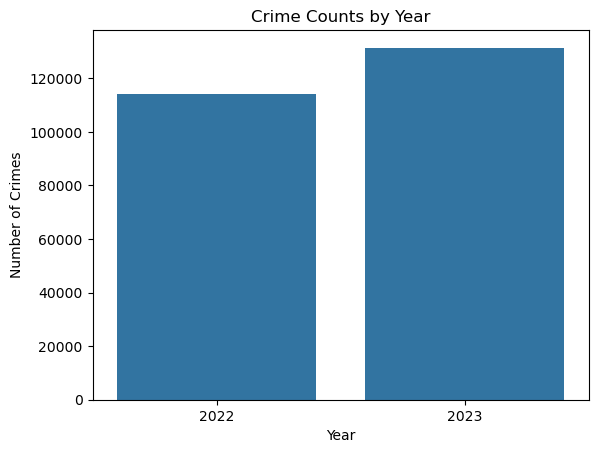

In [14]:
# Bar chart of crime counts by year
sns.countplot(x='year', data=df)
plt.title('Crime Counts by Year')
plt.xlabel('Year')
plt.ylabel('Number of Crimes')
plt.show()

#### 3.2.2 Top 10 Crime Types

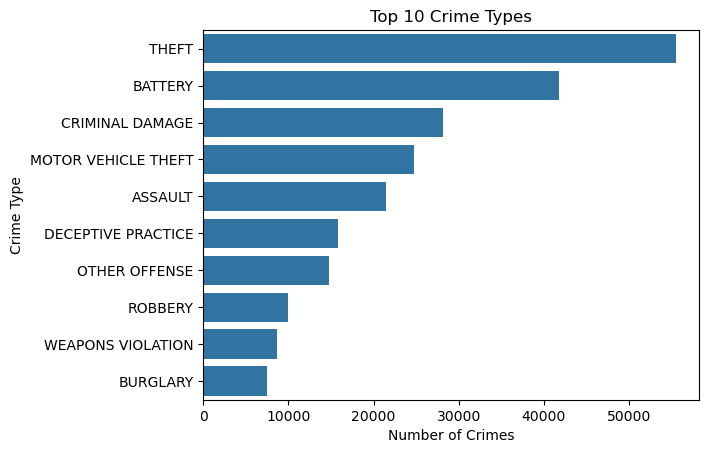

In [15]:
# Top 10 most frequent crimes
top_10_crimes = df['primary_type'].value_counts().nlargest(10)

# Bar plot of top 10 crimes
sns.barplot(x=top_10_crimes.values, y=top_10_crimes.index) #, palette='Blues_d'
plt.title('Top 10 Crime Types')
plt.xlabel('Number of Crimes')
plt.ylabel('Crime Type')
plt.show()

#### 3.2.3 Crimes by Location Description

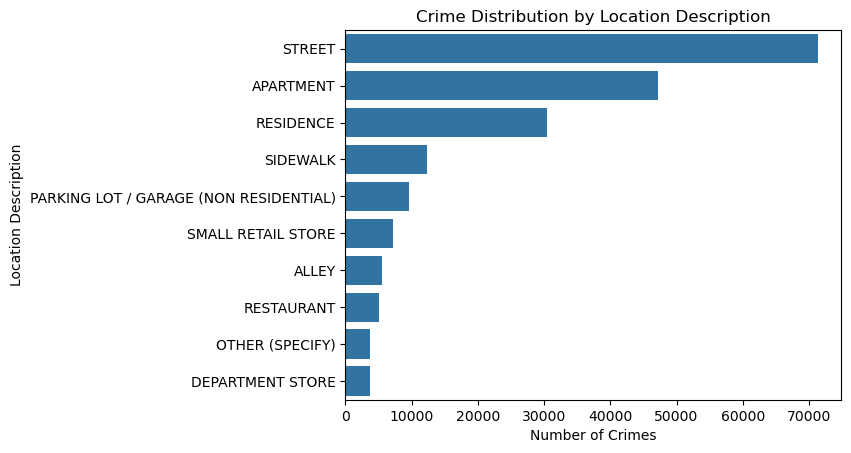

In [16]:
# Crime distribution by location type
location_counts = df['location_description'].value_counts().nlargest(10)

# Horizontal bar plot for crimes by location type
sns.barplot(x=location_counts.values, y=location_counts.index) # , palette='Greens_d'
plt.title('Crime Distribution by Location Description')
plt.xlabel('Number of Crimes')
plt.ylabel('Location Description')
plt.show()

#### 3.2.4 Crime Heatmap (Mapping Crimes)

In [17]:
# Create a map centered around Chicago
crime_map = folium.Map(location=[41.8781, -87.6298], zoom_start=11)

# Create a list of locations for the heatmap
heat_data = [[row['latitude'], row['longitude']] for index, row in df.dropna(subset=['latitude', 'longitude']).iterrows()]

# Add HeatMap layer to the map
HeatMap(heat_data).add_to(crime_map)

# Display map
crime_map.save("crime_heatmap.html")


#### 3.2.5 Seasonal Crime Distribution on a Map (on a randomly sampled 1000 data points)

In [18]:
# Create different marker clusters for Summer and Winter
summer_cluster = MarkerCluster(name='Summer Crimes').add_to(crime_map)
winter_cluster = MarkerCluster(name='Winter Crimes').add_to(crime_map)

# Sample 1000 rows for faster visualization
df_sample = df.sample(n=1000, random_state=42)

# Add markers for summer and winter crimes from the sample
for index, row in df_sample.iterrows():
    if row['season'] == 'Summer':
        folium.Marker(location=[row['latitude'], row['longitude']],
                      popup=row['primary_type'], 
                      icon=folium.Icon(color='blue')).add_to(summer_cluster)
    elif row['season'] == 'Winter':
        folium.Marker(location=[row['latitude'], row['longitude']],
                      popup=row['primary_type'], 
                      icon=folium.Icon(color='red')).add_to(winter_cluster)

# Save map
crime_map.save("seasonal_crime_map_subset.html")


#### 3.2.6 Crime Counts by Season

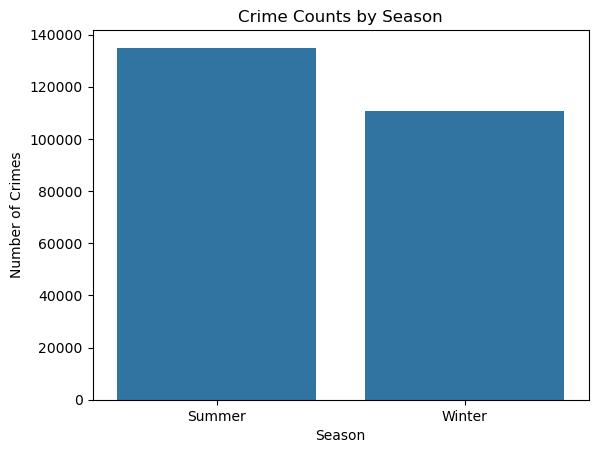

In [19]:
# Crime count comparison between seasons
season_counts = df['season'].value_counts()

# Bar plot for seasonal crime comparison
sns.barplot(x=season_counts.index, y=season_counts.values)
plt.title('Crime Counts by Season')
plt.xlabel('Season')
plt.ylabel('Number of Crimes')
plt.show()

#### 3.2.7 Primary Types by Season

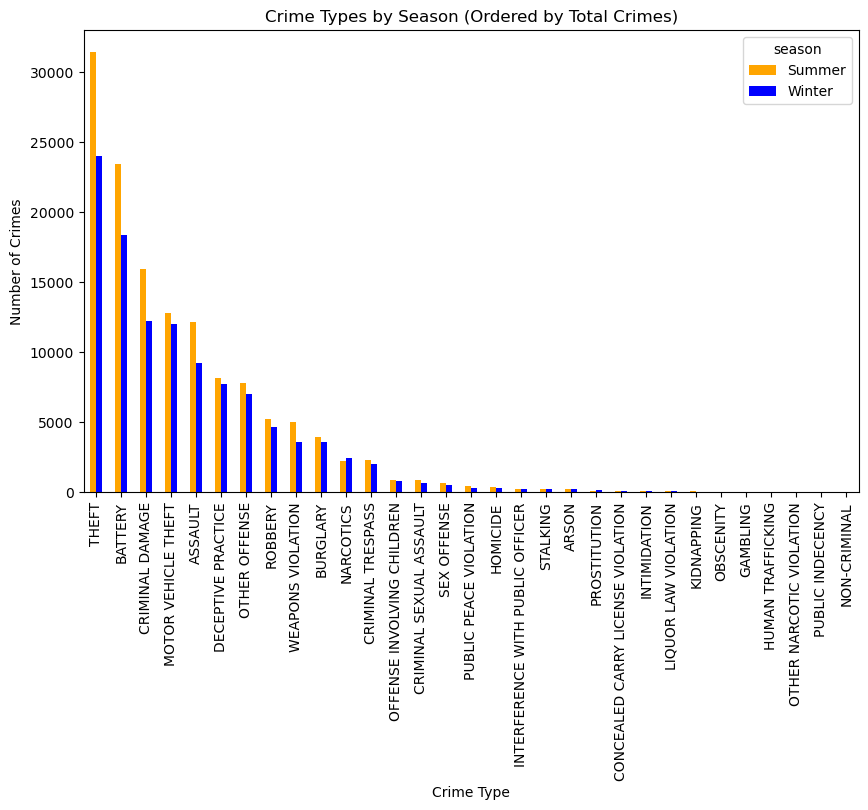

In [20]:
# Count of crime types by season
crime_season = df.groupby(['primary_type', 'season'])['unique_key'].count().unstack()

# Add a new column to calculate the total number of crimes for each crime type
crime_season['Total'] = crime_season.sum(axis=1)

# Sort the DataFrame by the 'Total' column in descending order
crime_season = crime_season.sort_values(by='Total', ascending=False)

# Drop the 'Total' column (optional, if you don't want it in the plot)
crime_season = crime_season.drop(columns='Total')

# Grouped bar plot with reversed color order (orange for summer, blue for winter)
colors = ['orange', 'blue']
crime_season[['Summer', 'Winter']].plot(kind='bar', stacked=False, figsize=(10,6), color=colors)
plt.title('Crime Types by Season (Ordered by Total Crimes)')
plt.xlabel('Crime Type')
plt.ylabel('Number of Crimes')
plt.show()

### 3.3 Visualizations based on Primary, Season and District

#### 3.3.1 Crime Counts by District and Season

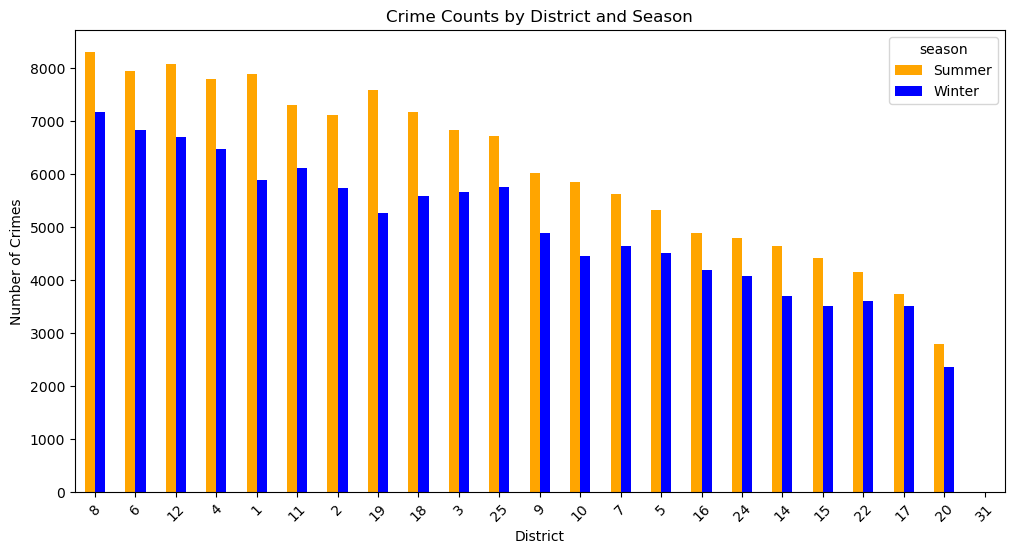

In [21]:
# Crime counts by district and season
district_season_counts = df.groupby(['district', 'season'])['unique_key'].count().unstack()

# Add a new column to calculate the total number of crimes for each crime type
district_season_counts['Total'] = district_season_counts.sum(axis=1)

# Sort the DataFrame by the 'Total' column in descending order
district_season_counts = district_season_counts.sort_values(by='Total', ascending=False)

# Drop the 'Total' column (optional, if you don't want it in the plot)
district_season_counts = district_season_counts.drop(columns='Total')

# Plotting grouped bar chart
district_season_counts.plot(kind='bar', figsize=(12,6), color=colors)
plt.title('Crime Counts by District and Season')
plt.xlabel('District')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=45)
plt.show()

#### 3.3.2 Top Crime Types by District

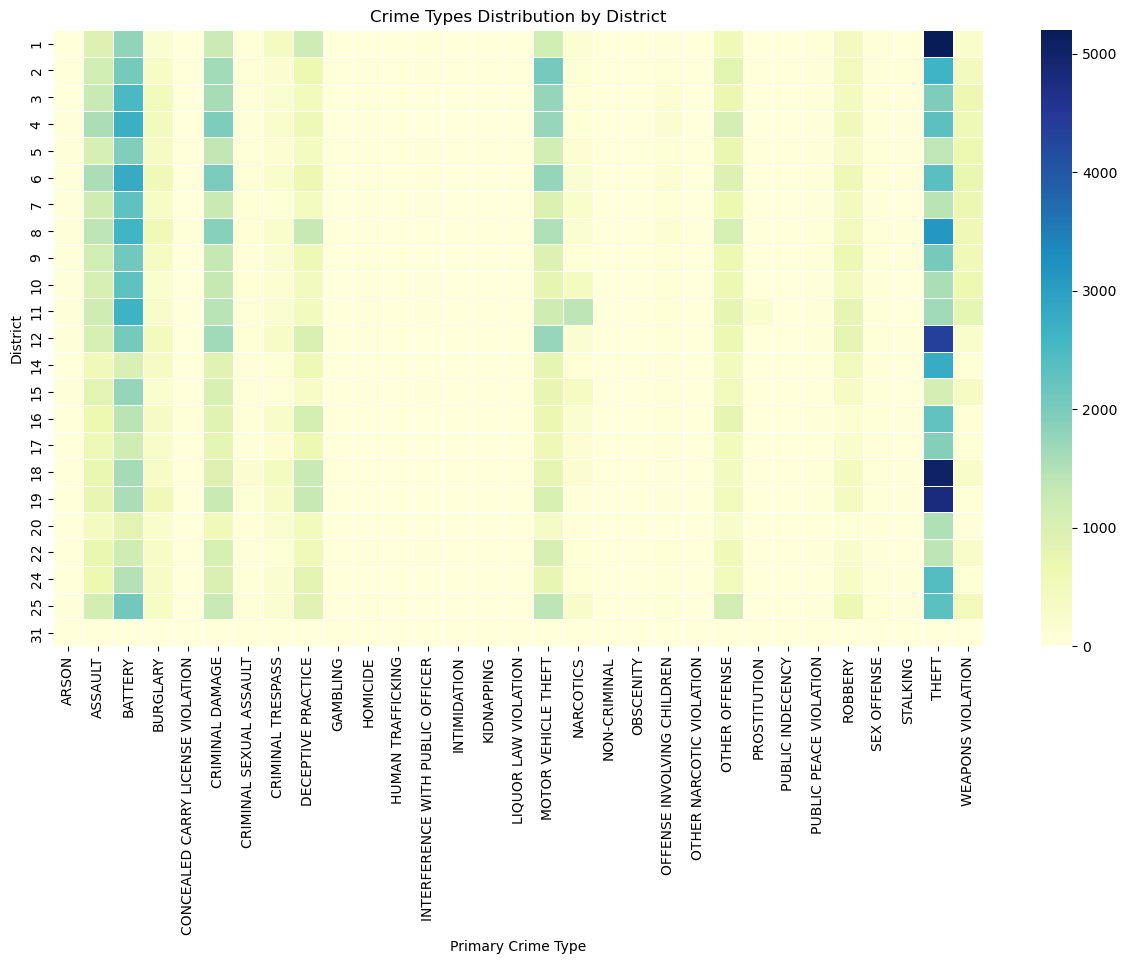

In [22]:
# Count of primary crime types by district
district_crime_types = df.groupby(['district', 'primary_type'])['unique_key'].count().unstack().fillna(0)

# Plot a heatmap to show the distribution of crime types by district
plt.figure(figsize=(15,8))
sns.heatmap(district_crime_types, cmap="YlGnBu", linewidths=0.5)
plt.title('Crime Types Distribution by District')
plt.xlabel('Primary Crime Type')
plt.ylabel('District')
plt.show()

#### 3.3.3 Seasonal Trends by District

In [23]:
# Count of crime types by district and season
district_season_crime = df.groupby(['season', 'district', 'primary_type'])['unique_key'].count().unstack(level=-1).fillna(0)
district_season_crime
# Plot for a specific district (e.g., district 1)
#district_1_crime = district_season_crime.loc[1]  # Example for District 1
#district_1_crime.plot(kind='bar', stacked=True, figsize=(10,6), color=['blue', 'orange'])
#plt.title('Crime Types by Season in District 1')
#plt.xlabel('Season')
#plt.ylabel('Number of Crimes')
#plt.xticks(rotation=0)
#plt.show()


primary_type     ARSON  ASSAULT  BATTERY  BURGLARY  \
season district                                      
Summer 1           4.0    528.0   1030.0      99.0   
       2           6.0    624.0   1128.0     150.0   
       3           7.0    698.0   1368.0     251.0   
       4          17.0    902.0   1512.0     273.0   
       5          15.0    581.0   1097.0     188.0   
       6          13.0    860.0   1480.0     286.0   
       7          17.0    636.0   1268.0     162.0   
       8          17.0    826.0   1442.0     282.0   
       9          15.0    684.0   1208.0     192.0   
       10         14.0    584.0   1318.0     100.0   
       11         22.0    682.0   1544.0     157.0   
       12         12.0    576.0   1144.0     259.0   
       14          7.0    286.0    580.0     176.0   
       15         13.0    450.0   1013.0      94.0   
       16          9.0    402.0    780.0     157.0   
       17          6.0    311.0    616.0     132.0   
       18          1.0    398.0    928.0     154.0   
       19          3.0    432.0    955.0     271.0   
       20          3.0    241.0    434.0      95.0   
       22          8.0    410.0    654.0     150.0   
       24         11.0    391.0    827.0     141.0   
       25         23.0    646.0   1126.0     161.0   
       31          0.0      1.0      0.0       0.0   
Winter 1           1.0    419.0    759.0      79.0   
       2          13.0    524.0    915.0     148.0   
       3           7.0    572.0   1134.0     245.0   
       4          12.0    656.0   1205.0     191.0   
       5           6.0    457.0    833.0     139.0   
       6          16.0    689.0   1313.0     268.0   
       7          21.0    536.0   1013.0     128.0   
       8          21.0    558.0   1158.0     265.0   
       9          14.0    464.0    885.0     189.0   
       10         16.0    432.0    970.0      87.0   
       11         18.0    490.0   1110.0      94.0   
       12         13.0    450.0    896.0     198.0   
       14          4.0    249.0    428.0     166.0   
       15         11.0    398.0    741.0      90.0   
       16          5.0    249.0    636.0     176.0   
       17          3.0    272.0    561.0     137.0   
       18          3.0    316.0    688.0     144.0   
       19          9.0    306.0    608.0     266.0   
       20          2.0    174.0    391.0     126.0   
       22          8.0    310.0    523.0     145.0   
       24          3.0    271.0    648.0     178.0   
       25          8.0    463.0    946.0     162.0   
       31          0.0      1.0      2.0       0.0   

primary_type     CONCEALED CARRY LICENSE VIOLATION  CRIMINAL DAMAGE  \
season district                                                       
Summer 1                                       0.0            725.0   
       2                                       2.0            953.0   
       3                                       1.0            932.0   
       4                                       4.0           1085.0   
       5                                       5.0            757.0   
       6                                       7.0           1129.0   
       7                                       7.0            692.0   
       8                                      28.0           1040.0   
       9                                       2.0            753.0   
       10                                      4.0            771.0   
       11                                      2.0            810.0   
       12                                      5.0            962.0   
       14                                      3.0            471.0   
       15                                      0.0            625.0   
       16                                     25.0            483.0   
       17                                      1.0            411.0   
       18                                      2.0            569.0   
       19                                      4.0        

#### 3.3.4 District-Wise Crime Counts by Season

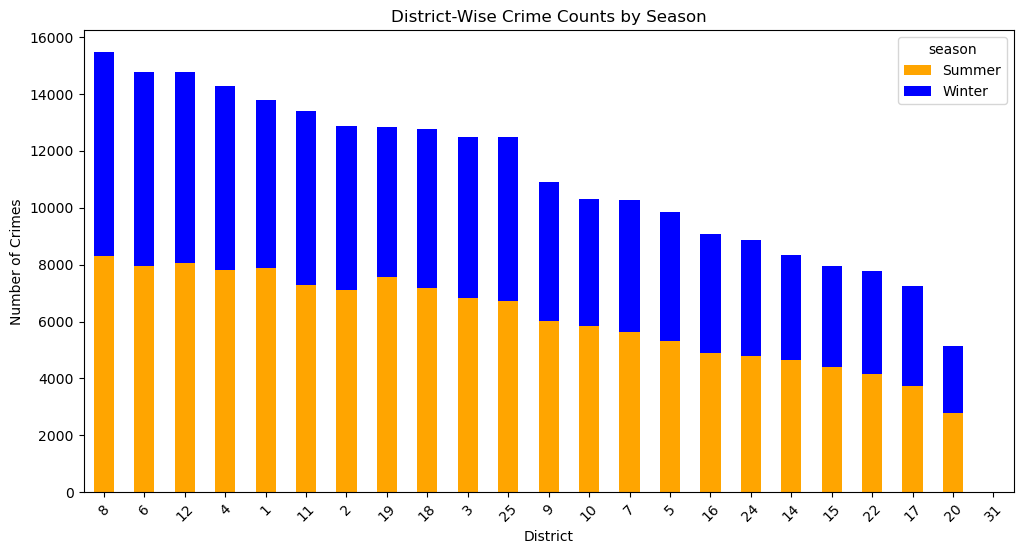

In [24]:
# Group by district and season, then count the number of crimes
district_season = df.groupby(['district', 'season'])['unique_key'].count().unstack()

# Add a new column to calculate the total number of crimes for each crime type
district_season['Total'] = district_season.sum(axis=1)

# Sort the DataFrame by the 'Total' column in descending order
district_season = district_season.sort_values(by='Total', ascending=False)

# Drop the 'Total' column (optional, if you don't want it in the plot)
district_season = district_season.drop(columns='Total')

# Stacked bar plot
district_season.plot(kind='bar', stacked=True, figsize=(12,6), color=['orange', 'blue'])
plt.title('District-Wise Crime Counts by Season')
plt.xlabel('District')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=45)
plt.show()


#### 3.3.5 District Map

In [25]:
# Create a folium map centered around Chicago
m = folium.Map(location=[41.8781, -87.6298], zoom_start=11)

# Create a color map for districts
import matplotlib.colors as mcolors

# Create a color map for each district
districts = df['district'].unique()
colors = plt.cm.rainbow(np.linspace(0, 1, len(districts)))
color_map = dict(zip(districts, colors))

# Plotting crime locations
for index, row in df.iterrows():
    district_color = color_map[row['district']]
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=3,
        color=mcolors.to_hex(district_color),
        fill=True,
        fill_color=mcolors.to_hex(district_color),
        fill_opacity=0.6,
        popup=f'District: {row["district"]}, Crime Type: {row["primary_type"]}',
        tooltip=f'District: {row["district"]}'
    ).add_to(m)

# Save the map
m.save('district_crime_map1.html')

# Display the map in a Jupyter notebook 
#m



In [27]:
import matplotlib.colors as mcolors

# Create a map centered around Chicago
m = folium.Map(location=[41.8781, -87.6298], zoom_start=11)

# Create a color map for each district
districts = df['district'].unique()
colors = plt.cm.rainbow(np.linspace(0, 1, len(districts)))
color_map = dict(zip(districts, colors))

# Plotting crime locations
for index, row in df.iterrows():
    district_color = color_map[row['district']]
    
    # Create an HTML string for the district label
    html = f'<div style="font-size: 12pt; color: black; background-color: {mcolors.to_hex(district_color)}; padding: 3px;">District {row["district"]}</div>'
    iframe = folium.IFrame(html, width=100, height=30)
    popup = folium.Popup(iframe, max_width=100)
    
    # Add CircleMarker for crimes
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color=mcolors.to_hex(district_color),
        fill=True,
        fill_color=mcolors.to_hex(district_color),
        fill_opacity=0.6,
        popup=popup
    ).add_to(m)

# Save the map
m.save('district_crime_map_with_labels1.html')

# Display the map in a Jupyter notebook 
#m


#### 3.3.6 District-Wise Theft Counts by Season

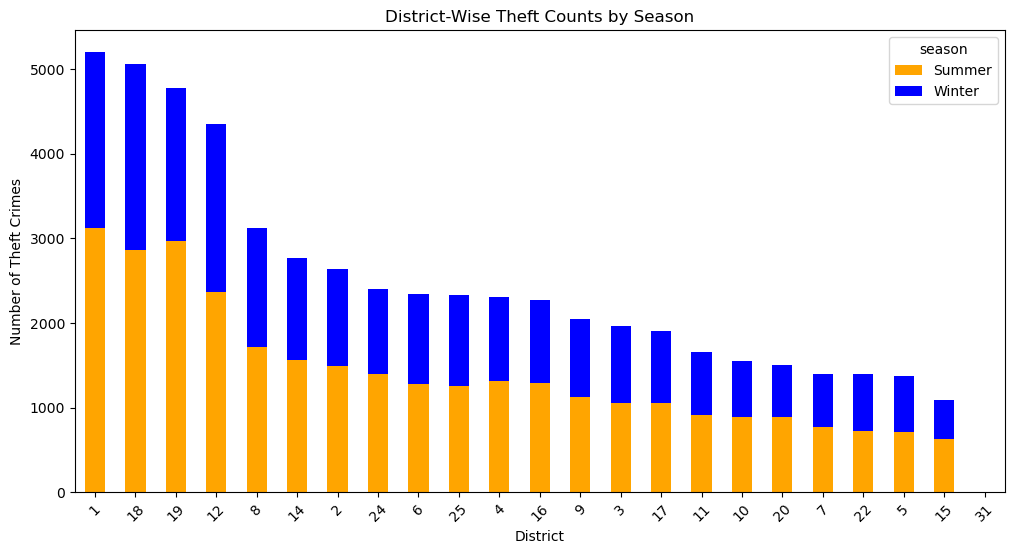

In [28]:
# Filter the DataFrame for theft crimes
theft_df = df[df['primary_type'] == 'THEFT']

# Group by district and season, then count the number of theft crimes
district_season_theft = theft_df.groupby(['district', 'season'])['unique_key'].count().unstack()

# Add a new column to calculate the total number of theft crimes
district_season_theft['Total'] = district_season_theft.sum(axis=1)

# Sort the DataFrame by the 'Total' column in descending order
district_season_theft = district_season_theft.sort_values(by='Total', ascending=False)

# Drop the 'Total' column (optional, if you don't want it in the plot)
district_season_theft = district_season_theft.drop(columns='Total')

# Stacked bar plot
district_season_theft.plot(kind='bar', stacked=True, figsize=(12,6), color=['orange', 'blue'])
plt.title('District-Wise Theft Counts by Season')
plt.xlabel('District')
plt.ylabel('Number of Theft Crimes')
plt.xticks(rotation=45)
plt.show()

## 4. Performing a hypothesis test

### 4.1. Independent t-test - Daily Theft Counts per Season T-Test

H0 = No significant difference in theft crime counts between seasons.

H1 = Theft crime counts significantly differ between seasons.

In [29]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Extract day information
df['day'] = df['date'].dt.date

In [30]:

# Filter for theft crimes
theft_df = df[df['primary_type'] == 'THEFT']
len(theft_df)

55445

In [31]:
# Aggregate theft counts by day and season
theft_counts = theft_df.groupby(['day', 'season']).size().reset_index(name='daily_count')
theft_counts

,day,season,daily_count
0,2022-01-01,Winter,123
1,2022-01-02,Winter,85
2,2022-01-03,Winter,98
3,2022-01-04,Winter,118
4,2022-01-05,Winter,99
...,...,...,...
359,2023-12-27,Winter,136
360,2023-12-28,Winter,166
361,2023-12-29,Winter,158
362,2023-12-30,Winter,183


In [32]:
# Split data into summer and winter thefts
summer_theft = theft_counts[theft_counts['season'] == 'Summer']['daily_count']
winter_theft = theft_counts[theft_counts['season'] == 'Winter']['daily_count']

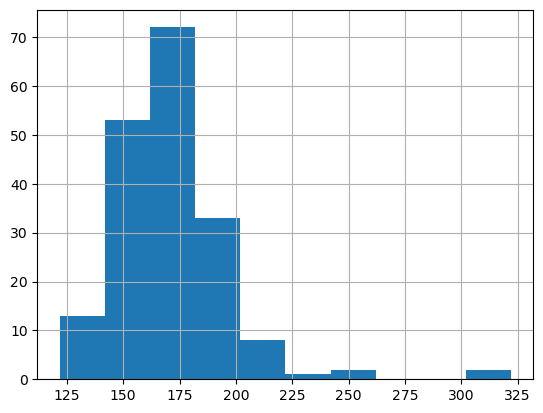

In [33]:
summer_theft.hist();

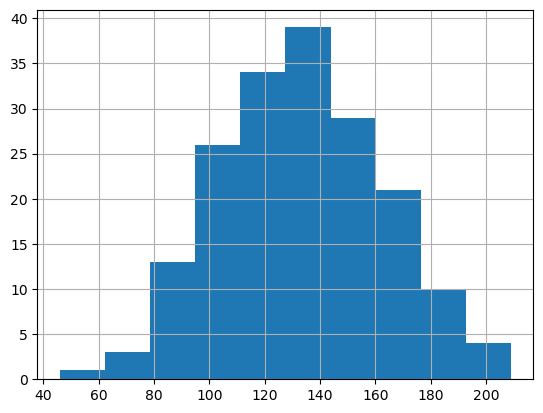

In [34]:
winter_theft.hist();

In [35]:
# Making sure that I have equal samples from each group
summer_theft = summer_theft.sample(100, random_state = 42)
winter_theft = winter_theft.sample(100, random_state = 42)

In [36]:
# Calculating variances
summer_var = summer_theft.var(ddof = 1)
winter_var = winter_theft.var(ddof = 1)

summer_var, winter_var

(451.5842424242424, 725.420101010101)

In [37]:
# Calculating pooled standard deviation
std = np.sqrt((summer_var + winter_var) /2)
std

24.259063702401452

In [38]:
# Calculating test statistic
t = (summer_theft.mean() - winter_theft.mean()) / (std * np.sqrt(2 / 100))
t

12.169351825237984

In [39]:
# Calculating degrees of freedom
ddof = 2 * 100 - 2
ddof

198

In [40]:
# Finding the P-value
p = 1 - stats.t.cdf(abs(t), df=ddof)  # #p-value after comparison with the t
print("t = " + str(t))
print("p = " + str(2 * p))

t = 12.169351825237984
p = 0.0


In [41]:
# Interpreting the results
null_hypothesis = {
                "H0" : "No significant difference in theft crime counts between seasons.",
                "H1" : "Theft crime counts significantly differ between seasons."
}

In [42]:
alpha = 0.05

In [43]:
# Helper function to interpret the results
def print_sig(p_value, alpha):
    '''
    Inputs:
    p_value: Calculated p_value
    alpha: Confidence level
    '''
    if p_value < alpha:
        print("We reject our null hypothesis.")
        print(null_hypothesis['H1'])
    elif p_value > alpha:
        print("We fail to reject our null hypothesis.")
        print(null_hypothesis['H0'])
    else:
        print("Our test is inconclusive.")

In [44]:
print("t = " + str(t))
print("p = " + str(p*2))
print_sig(p*2, alpha)

t = 12.169351825237984
p = 0.0
We reject our null hypothesis.
Theft crime counts significantly differ between seasons.


In [45]:
# SANITY CHECK -- Using t-test to compare theft crimes between winter and summer
t_stat, p_value = ttest_ind(winter_theft, summer_theft)  # Welch's t-test
print(f"T-statistic: {t_stat}, P-value: {p_value}")


T-statistic: -12.169351825237982, P-value: 8.400034909564936e-26


In [46]:
# Setting alpha to 0.05
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis - theft crime counts significantly differ between seasons.")
else:
    print("Fail to reject the null hypothesis - no significant difference in theft crime counts between seasons.")

Reject the null hypothesis - theft crime counts significantly differ between seasons.


### 4.2 Helper Hypothesis Decision visualization

In [47]:
def hypothesis_decision(t, p, alpha=0.05):
    """
    Plots the standard normal distribution and highlights the critical regions
    for a two-tailed t-test based on the provided t-statistic and p-value.

    Parameters:
    - t: float
        The t-statistic value from the t-test.
    - p: float
        The p-value from the t-test.
    - alpha: float, optional (default=0.05)
        The significance level for the hypothesis test.
    """
    # Generate data for a standard normal distribution
    x = np.linspace(-4, 4, 1000)
    y = stats.norm.pdf(x, loc=0, scale=1)

    # Define critical t value for illustration
    t_critical = stats.norm.ppf(1 - alpha / 2)  # Critical value for the given alpha

    # Decision based on p-value
    decision = "Decision: Reject H0" if p < alpha else "Decision: Fail to Reject H0"

    # Create the plot
    plt.figure(figsize=(10, 6))
    plt.plot(x, y, label='Standard Normal Distribution', color='blue')

    # Highlight critical regions for a two-tailed test in red
    plt.fill_between(x, y, where=(x > t_critical), color='red', alpha=0.3, label='Reject H0 (Critical Region)')
    plt.fill_between(x, y, where=(x < -t_critical), color='red', alpha=0.3)

    # Shade the alpha level in gray
    plt.fill_between(x, y, where=(x > t_critical), color='gray', alpha=0.2, label=f'Alpha = {alpha}')
    plt.fill_between(x, y, where=(x < -t_critical), color='gray', alpha=0.2)

    # Add labels and title
    plt.xlabel('t-statistic')
    plt.ylabel('Probability Density')
    plt.title('Two-Tailed t-Test')
    plt.axvline(x=t_critical, color='black', linestyle='--', label=f't_critical = {t_critical:.2f}')
    plt.axvline(x=-t_critical, color='black', linestyle='--')

    # Add the actual t-statistic line and p-value annotation
    plt.axvline(x=t, color='green', linestyle='--', label=f'actual t = {t:.2f}')
    plt.text(t, 0.1, f'actual t = {t:.2f}\nactual p = {p:.4f}', ha='center', va='bottom', color='red', fontsize=10)

    # Add the decision annotation
    plt.text(0, 0.3, decision, ha='center', va='bottom', color='black', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

    # Add legend and move it to the top right corner
    plt.legend(loc='upper right')

    # Show the plot
    plt.grid(True)
    plt.show()

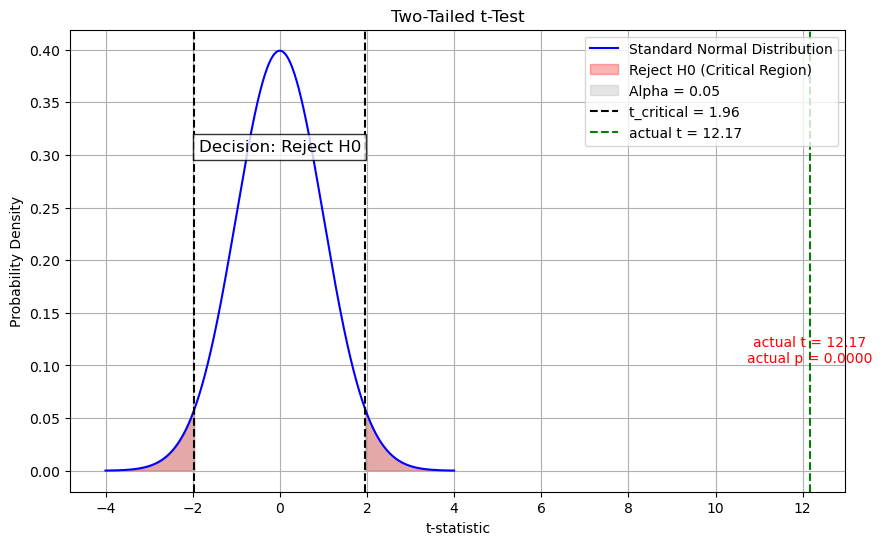

In [48]:
hypothesis_decision(t, p, alpha)